# Evaluating the Corrected Output in the Dual-Injection Condition

## Overview

The previous section established the uncorrected baseline for the dual-injection condition and showed that the mixed response retained a residual green-derived component. In the present section, the validated correction algorithm was applied to the same dual-injection framework to determine whether that residual contribution could be reduced and whether the mixed response could be interpreted more specifically within the red measurement range.

The following comparisons evaluate the corrected result at the reward-aligned, normalized-response, and direct-comparison levels. This structure makes it possible to assess not only how the corrected output appears on its own, but also whether algorithmic correction produces a measurable shift away from the uncorrected green-biased baseline.

## Reward-Aligned Responses After Algorithmic Correction

The first step was to examine how the dual-injection recording appeared after application of the correction algorithm under the same excitation condition used in the uncorrected baseline. At the time-series level, this comparison was used to determine whether the corrected mixed response became less similar to the green-associated response pattern and more consistent with a cleaner red-channel interpretation.

The corrected reward-aligned traces were therefore compared directly with the corresponding uncorrected traces so that the immediate effect of the algorithm on event-related signal dynamics could be evaluated.

Corrected and uncorrected comparison datasets loaded successfully.
Unified Y-axis range → [-56.457, 500.421]


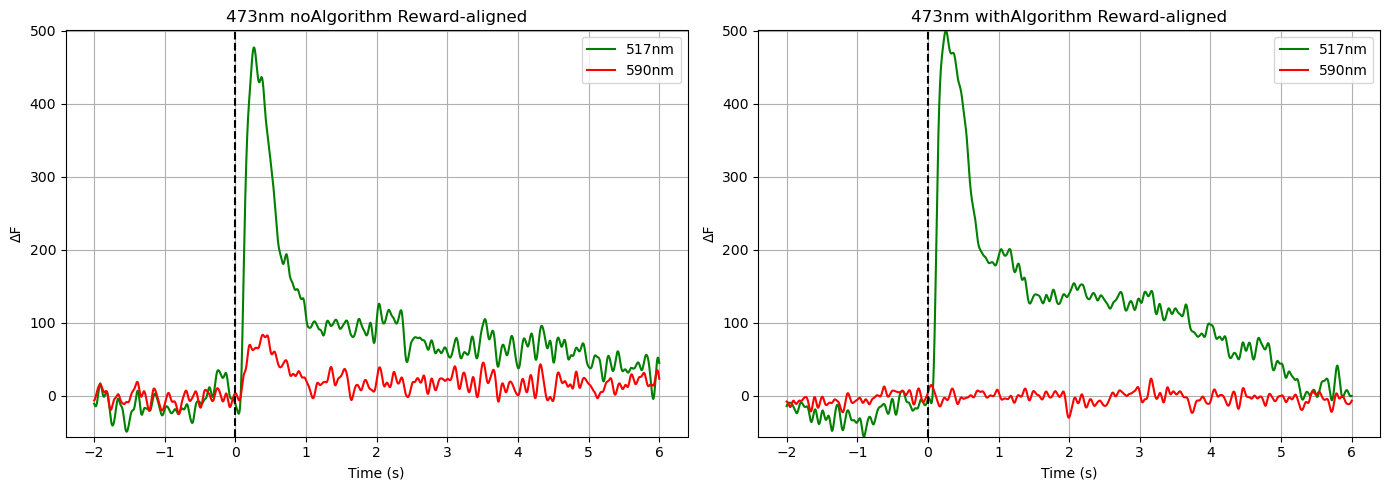

In [1]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

def load_stimuli_file(mat_path):
    """Load a standardized stimuli dataset for corrected dual-injection comparison."""
    data = loadmat(mat_path)

    photo1 = data["photo1"].flatten()
    photo2 = data["photo2"].flatten()
    sol1times = data["sol1times"].flatten()
    downsamplingrate = int(data["downsamplingrate"][0][0])

    return photo1, photo2, sol1times, downsamplingrate

# Load matched sample datasets for direct comparison between
# the uncorrected and corrected dual-injection conditions
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "stimuli_file" / "GCaMP+jRGECO"

file_no_algo = DATA_DIR / "Flna30_473nm_stimuli_python.mat"
file_with_algo = DATA_DIR / "ALG_Flna30_473nm_stimuli_python.mat"

photo1_noAlgo, photo2_noAlgo, sol1_noAlgo, rate_noAlgo = load_stimuli_file(file_no_algo)
photo1_withAlgo, photo2_withAlgo, sol1_withAlgo, rate_withAlgo = load_stimuli_file(file_with_algo)

print("Corrected and uncorrected comparison datasets loaded successfully.")

def compute_reward_aligned(photo1, photo2, sol1times, rate):
    pre, post = 2, 6

    photometry1_sol1 = []
    photometry2_sol1 = []

    for t in sol1times:
        idx = int(t * rate)

        start = idx - int(pre * rate)
        end = idx + int(post * rate)

        if start >= 0 and end < len(photo1):

            base_start = idx - int(3 * rate)
            base_end = idx - int(2 * rate)

            baseline1 = np.mean(photo1[base_start:base_end])
            baseline2 = np.mean(photo2[base_start:base_end])

            segment1 = photo1[start:end] - baseline1
            segment2 = photo2[start:end] - baseline2

            photometry1_sol1.append(segment1)
            photometry2_sol1.append(segment2)

    photometry1_sol1 = np.array(photometry1_sol1)
    photometry2_sol1 = np.array(photometry2_sol1)

    time_axis = np.linspace(-pre, post, photometry1_sol1.shape[1])

    return photometry1_sol1, photometry2_sol1, time_axis

p1_noAlgo, p2_noAlgo, t_noAlgo = compute_reward_aligned(
    photo1_noAlgo, photo2_noAlgo, sol1_noAlgo, rate_noAlgo
)

p1_withAlgo, p2_withAlgo, t_withAlgo = compute_reward_aligned(
    photo1_withAlgo, photo2_withAlgo, sol1_withAlgo, rate_withAlgo
)

ymin_noAlgo = np.min([p1_noAlgo.mean(axis=0), p2_noAlgo.mean(axis=0)])
ymax_noAlgo = np.max([p1_noAlgo.mean(axis=0), p2_noAlgo.mean(axis=0)])

ymin_withAlgo = np.min([p1_withAlgo.mean(axis=0), p2_withAlgo.mean(axis=0)])
ymax_withAlgo = np.max([p1_withAlgo.mean(axis=0), p2_withAlgo.mean(axis=0)])

ymin = min(ymin_noAlgo, ymin_withAlgo)
ymax = max(ymax_noAlgo, ymax_withAlgo)

print(f"Unified Y-axis range → [{ymin:.3f}, {ymax:.3f}]")

plt.figure(figsize=(14, 5))

# ---- LEFT: 473nm noAlgorithm ----
plt.subplot(1, 2, 1)
plt.plot(t_noAlgo, p1_noAlgo.mean(axis=0), color='green', label='517nm')
plt.plot(t_noAlgo, p2_noAlgo.mean(axis=0), color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('Uncorrected dual-injection response under 473 nm excitation')
plt.xlabel('Time (s)')
plt.ylabel('ΔF')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

# ---- RIGHT: 473nm withAlgorithm ----
plt.subplot(1, 2, 2)
plt.plot(t_withAlgo, p1_withAlgo.mean(axis=0), color='green', label='517nm')
plt.plot(t_withAlgo, p2_withAlgo.mean(axis=0), color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('Corrected dual-injection response under 473 nm excitation')
plt.xlabel('Time (s)')
plt.ylabel('ΔF')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

plt.tight_layout()
plt.show()

**Figure 1. Reward-aligned comparison of uncorrected and corrected dual-injection responses.**  
Reward-aligned fluorescence traces from the dual-injection condition were compared before and after application of the correction algorithm under the same 473 nm excitation condition. Relative to the uncorrected response, the corrected output shows reduced green-associated influence within the mixed signal and provides the first time-domain view of the algorithmic effect.

## Standardized Comparison of the Corrected Mixed Response

Because direct comparison across excitation conditions is clearer after normalization, the corrected dual-injection responses were also evaluated on a z-score scale. This standardized view placed the corrected mixed response and the uncorrected baseline on a common metric and allowed the effect of correction on the residual green-associated component to be assessed more directly.

The normalized comparison therefore served as an intermediate performance check before the corrected and uncorrected mixed conditions were contrasted more explicitly in the following section.

Corrected and uncorrected comparison datasets loaded successfully.
Valid trials (473nm noAlgorithm): 30
Valid trials (473nm withAlgorithm): 50
Unified Y-axis range (z-score) → [-0.723, 7.300]


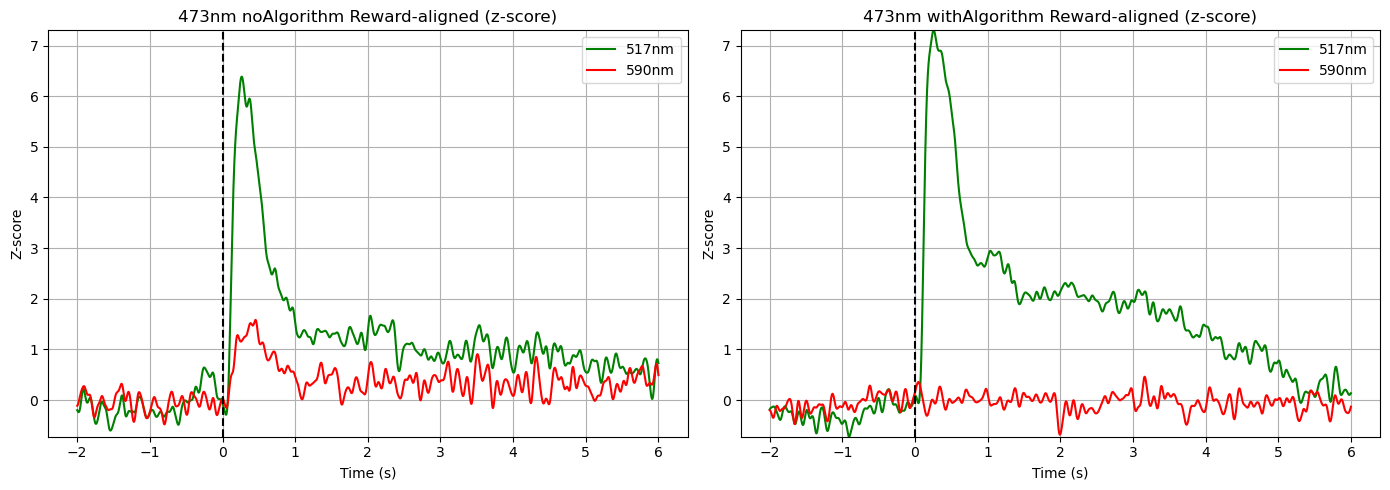

In [2]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

def load_stimuli_file(mat_path):
    """Load a standardized stimuli dataset for corrected dual-injection comparison."""
    data = loadmat(mat_path)

    photo1 = data["photo1"].flatten()
    photo2 = data["photo2"].flatten()
    sol1times = data["sol1times"].flatten()
    downsamplingrate = int(data["downsamplingrate"][0][0])

    return photo1, photo2, sol1times, downsamplingrate

# Load matched sample datasets for direct comparison between
# the uncorrected and corrected dual-injection conditions
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "stimuli_file" / "GCaMP+jRGECO"

file_no_algo = DATA_DIR / "Flna30_473nm_stimuli_python.mat"
file_with_algo = DATA_DIR / "ALG_Flna30_473nm_stimuli_python.mat"

photo1_noAlgo, photo2_noAlgo, sol1_noAlgo, rate_noAlgo = load_stimuli_file(file_no_algo)
photo1_withAlgo, photo2_withAlgo, sol1_withAlgo, rate_withAlgo = load_stimuli_file(file_with_algo)

print("Corrected and uncorrected comparison datasets loaded successfully.")

def compute_reward_aligned_zscore(photo1, photo2, sol1times, rate):
    pre, post = 2, 6

    zphoto1_trials = []
    zphoto2_trials = []

    for t in sol1times:
        idx = int(t * rate)

        start = idx - int(pre * rate)
        end   = idx + int(post * rate)

        base_start = idx - int(3 * rate)
        base_end   = idx - int(2 * rate)

        if start >= 0 and end < len(photo1) and base_start >= 0 and base_end < len(photo1):

            base1 = photo1[base_start:base_end]
            base2 = photo2[base_start:base_end]

            mean1 = np.mean(base1)
            std1  = np.std(base1)
            mean2 = np.mean(base2)
            std2  = np.std(base2)

            if std1 < 1e-6 or std2 < 1e-6:
                continue

            seg1 = photo1[start:end]
            seg2 = photo2[start:end]

            zseg1 = (seg1 - mean1) / std1
            zseg2 = (seg2 - mean2) / std2

            zphoto1_trials.append(zseg1)
            zphoto2_trials.append(zseg2)

    zphoto1_trials = np.array(zphoto1_trials)
    zphoto2_trials = np.array(zphoto2_trials)

    if len(zphoto1_trials) == 0:
        raise ValueError("No valid reward-aligned z-score trials found.")

    time_vec = np.linspace(-pre, post, zphoto1_trials.shape[1])

    return zphoto1_trials, zphoto2_trials, time_vec

z1_noAlgo, z2_noAlgo, t_noAlgo = compute_reward_aligned_zscore(
    photo1_noAlgo, photo2_noAlgo, sol1_noAlgo, rate_noAlgo
)

z1_withAlgo, z2_withAlgo, t_withAlgo = compute_reward_aligned_zscore(
    photo1_withAlgo, photo2_withAlgo, sol1_withAlgo, rate_withAlgo
)

print(f"Valid trials (473nm noAlgorithm): {z1_noAlgo.shape[0]}")
print(f"Valid trials (473nm withAlgorithm): {z1_withAlgo.shape[0]}")

ymin_noAlgo = np.min([z1_noAlgo.mean(axis=0), z2_noAlgo.mean(axis=0)])
ymax_noAlgo = np.max([z1_noAlgo.mean(axis=0), z2_noAlgo.mean(axis=0)])

ymin_withAlgo = np.min([z1_withAlgo.mean(axis=0), z2_withAlgo.mean(axis=0)])
ymax_withAlgo = np.max([z1_withAlgo.mean(axis=0), z2_withAlgo.mean(axis=0)])

ymin = min(ymin_noAlgo, ymin_withAlgo)
ymax = max(ymax_noAlgo, ymax_withAlgo)

print(f"Unified Y-axis range (z-score) → [{ymin:.3f}, {ymax:.3f}]")

plt.figure(figsize=(14, 5))

# ---- LEFT: 473nm noAlgorithm ----
plt.subplot(1, 2, 1)
plt.plot(t_noAlgo, z1_noAlgo.mean(axis=0), color='green', label='517nm')
plt.plot(t_noAlgo, z2_noAlgo.mean(axis=0), color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('Uncorrected dual-injection response under 473 nm excitation (z-score)')
plt.xlabel('Time (s)')
plt.ylabel('Z-score')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

# ---- RIGHT: 473nm withAlgorithm ----
plt.subplot(1, 2, 2)
plt.plot(t_withAlgo, z1_withAlgo.mean(axis=0), color='green', label='517nm')
plt.plot(t_withAlgo, z2_withAlgo.mean(axis=0), color='red', label='590nm')
plt.axvline(0, linestyle='--', color='black')
plt.title('Corrected dual-injection response under 473 nm excitation (z-score)')
plt.xlabel('Time (s)')
plt.ylabel('Z-score')
plt.legend()
plt.grid()
plt.ylim(ymin, ymax)

plt.tight_layout()
plt.show()

**Figure 2. Standardized comparison of the dual-injection response before and after correction.**  
The uncorrected and corrected dual-injection responses were transformed to z-scores so that their event-related patterns could be compared on a common scale. After normalization, the corrected mixed response shows a measurable shift away from the green-biased uncorrected baseline, supporting the view that algorithmic correction reduced the residual contamination component.

## Direct Comparison Between the Uncorrected and Corrected Mixed Conditions

The most direct test of algorithmic correction was obtained by comparing the uncorrected and corrected mixed responses under the same dual-injection condition. Distribution-based summaries such as dot plots or violin plots were used to evaluate whether the corrected mixed response shifted away from the green-biased uncorrected baseline and toward a cleaner red-channel interpretation.

This comparison provided the clearest performance-level readout of the algorithm. Rather than asking only whether the corrected signal looked visually different, the comparison asked whether correction produced a measurable reduction in the residual green-derived component that had defined the limitation of the uncorrected baseline.

Corrected and uncorrected comparison datasets loaded successfully.

Loading: Flna30_473nm_stimuli_python.mat
Loading: ALG_Flna30_473nm_stimuli_python.mat


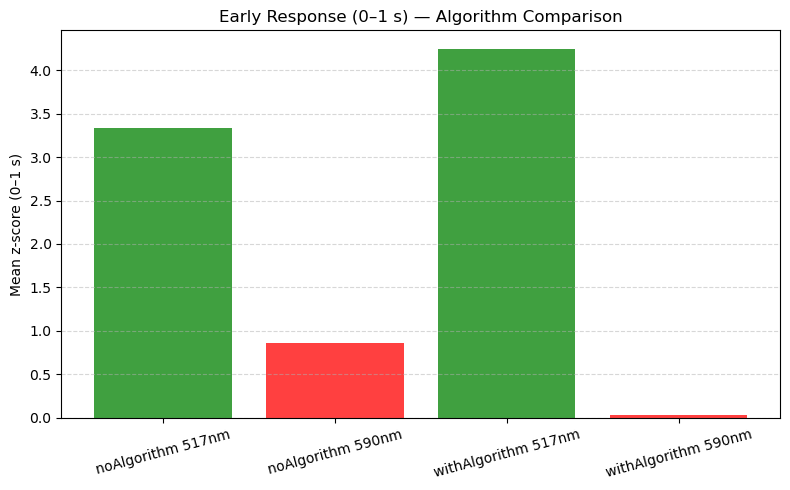

In [8]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

def load_stimuli_file(mat_path):
    """Load a standardized stimuli dataset for corrected dual-injection comparison."""
    data = loadmat(mat_path)

    photo1 = data["photo1"].flatten()
    photo2 = data["photo2"].flatten()
    sol1times = data["sol1times"].flatten()
    downsamplingrate = int(data["downsamplingrate"][0][0])

    return photo1, photo2, sol1times, downsamplingrate

# Load matched sample datasets for direct comparison between
# the uncorrected and corrected dual-injection conditions
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "stimuli_file" / "GCaMP+jRGECO"

file_no_algo = DATA_DIR / "Flna30_473nm_stimuli_python.mat"
file_with_algo = DATA_DIR / "ALG_Flna30_473nm_stimuli_python.mat"

photo1_noAlgo, photo2_noAlgo, sol1_noAlgo, rate_noAlgo = load_stimuli_file(file_no_algo)
photo1_withAlgo, photo2_withAlgo, sol1_withAlgo, rate_withAlgo = load_stimuli_file(file_with_algo)

print("Corrected and uncorrected comparison datasets loaded successfully.")

def compute_reward_aligned_zscore(photo1, photo2, sol1times, rate):
    pre, post = 2, 6
    zphoto1 = []
    zphoto2 = []

    for t in sol1times:
        idx = int(t * rate)
        start = idx - int(pre * rate)
        end   = idx + int(post * rate)

        if start < 0 or end >= len(photo1):
            continue

        base_start = idx - int(3 * rate)
        base_end   = idx - int(2 * rate)

        if base_start < 0 or base_end > len(photo1):
            continue

        b1 = photo1[base_start:base_end]
        b2 = photo2[base_start:base_end]

        m1, s1 = np.mean(b1), np.std(b1)
        m2, s2 = np.mean(b2), np.std(b2)

        if s1 < 1e-6 or s2 < 1e-6:
            continue

        seg1 = photo1[start:end]
        seg2 = photo2[start:end]

        zseg1 = (seg1 - m1) / s1
        zseg2 = (seg2 - m2) / s2

        zphoto1.append(zseg1)
        zphoto2.append(zseg2)

    zphoto1 = np.array(zphoto1)
    zphoto2 = np.array(zphoto2)

    if len(zphoto1) == 0:
        raise ValueError("No valid trials found for z-score calculation.")

    time_vec = np.linspace(-pre, post, zphoto1.shape[1])
    return zphoto1, zphoto2, time_vec

def compute_early_response(z1, z2, time_vec):
    idx0 = np.argmin(np.abs(time_vec - 0))
    idx1 = np.argmin(np.abs(time_vec - 1))

    r1 = z1[:, idx0:idx1].mean(axis=1)
    r2 = z2[:, idx0:idx1].mean(axis=1)

    return r1.mean(), r2.mean()

if __name__ == "__main__":

    print(f"\nLoading: {file_no_algo.name}")
    p1_noAlgo, p2_noAlgo, sol1_noAlgo, rate_noAlgo = load_stimuli_file(file_no_algo)

    print(f"Loading: {file_with_algo.name}")
    p1_withAlgo, p2_withAlgo, sol1_withAlgo, rate_withAlgo = load_stimuli_file(file_with_algo)

    z1_noAlgo, z2_noAlgo, t_noAlgo = compute_reward_aligned_zscore(
        p1_noAlgo, p2_noAlgo, sol1_noAlgo, rate_noAlgo
    )

    z1_withAlgo, z2_withAlgo, t_withAlgo = compute_reward_aligned_zscore(
        p1_withAlgo, p2_withAlgo, sol1_withAlgo, rate_withAlgo
    )

    r1_noAlgo, r2_noAlgo = compute_early_response(z1_noAlgo, z2_noAlgo, t_noAlgo)
    r1_withAlgo, r2_withAlgo = compute_early_response(z1_withAlgo, z2_withAlgo, t_withAlgo)

    labels = [
        'noAlgorithm 517nm',
        'noAlgorithm 590nm',
        'withAlgorithm 517nm',
        'withAlgorithm 590nm'
    ]
    values = [r1_noAlgo, r2_noAlgo, r1_withAlgo, r2_withAlgo]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=['green', 'red', 'green', 'red'], alpha=0.75)
    plt.ylabel("Mean z-score (0–1 s)")
    plt.title("Early Response (0–1 s) — Algorithm Comparison")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=15)

    plt.tight_layout()
    plt.show()

**Figure 3. Bar-based summary of early reward-aligned responses before and after correction.**  
Mean z-score values within the 0–1 s post-reward interval were summarized for the 517 nm and 590 nm signals in the uncorrected and corrected dual-injection conditions. The bar plot provides a compact comparison of how the early mixed response changed after algorithmic correction and makes the reduction of the residual green-associated component easier to compare at a glance.

Corrected and uncorrected comparison datasets loaded successfully.

Loading: Flna30_473nm_stimuli_python.mat
Loading: ALG_Flna30_473nm_stimuli_python.mat
[DEBUG] trials=30, nT=18000, time range=(-3.000,6.000)
[DEBUG] trials=50, nT=18000, time range=(-3.000,6.000)

Trials (noAlgorithm 590nm): 30, mean=0.861
Trials (withAlgorithm 590nm): 50, mean=0.031

===== 590 contamination index summary =====
[noAlgorithm]  n=30 mean=0.8608  bootstrap95%CI=(0.5884, 1.1410)
[withAlgorithm] n=50 mean=0.0308  bootstrap95%CI=(-0.1571, 0.2267)


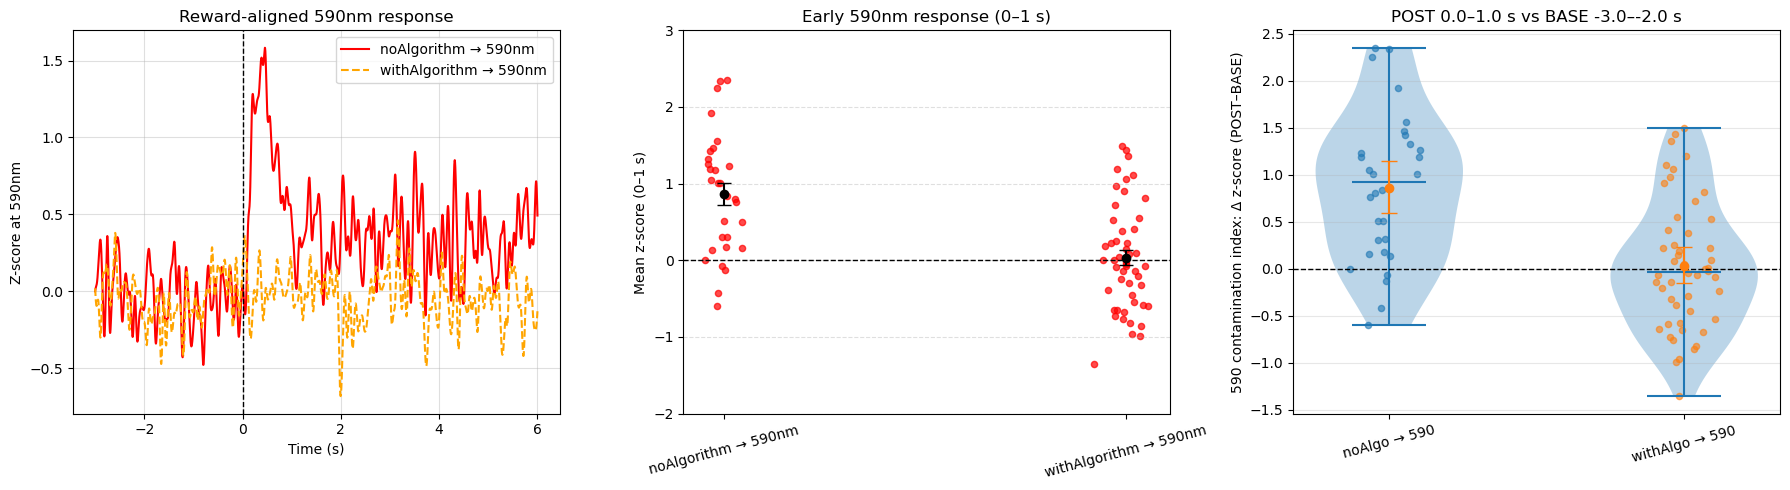

In [10]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

def load_stimuli_file(mat_path):
    """Load a standardized stimuli dataset for corrected dual-injection comparison."""
    data = loadmat(mat_path)

    photo1 = data["photo1"].flatten()
    photo2 = data["photo2"].flatten()
    sol1times = data["sol1times"].flatten()
    downsamplingrate = int(data["downsamplingrate"][0][0])

    return photo1, photo2, sol1times, downsamplingrate

# Load matched sample datasets for direct comparison between
# the uncorrected and corrected dual-injection conditions
NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data" / "stimuli_file" / "GCaMP+jRGECO"

file_no_algo = DATA_DIR / "Flna30_473nm_stimuli_python.mat"
file_with_algo = DATA_DIR / "ALG_Flna30_473nm_stimuli_python.mat"

photo1_noAlgo, photo2_noAlgo, sol1_noAlgo, rate_noAlgo = load_stimuli_file(file_no_algo)
photo1_withAlgo, photo2_withAlgo, sol1_withAlgo, rate_withAlgo = load_stimuli_file(file_with_algo)

print("Corrected and uncorrected comparison datasets loaded successfully.")

def compute_reward_aligned_zscore(photo1, photo2, sol1times, rate, pre=3, post=6):
    
    zphoto1 = []
    zphoto2 = []
    n = len(photo1)

    for t in sol1times:
        idx = int(t * rate)

        start = idx - int(pre * rate)
        end   = idx + int(post * rate)

        if start < 0 or end > n:
            continue

        # baseline: -3 ~ -2 s
        base_start = idx - int(3 * rate)
        base_end   = idx - int(2 * rate)

        if base_start < 0 or base_end > n:
            continue

        b1 = photo1[base_start:base_end]
        b2 = photo2[base_start:base_end]

        mean1, std1 = np.mean(b1), np.std(b1)
        mean2, std2 = np.mean(b2), np.std(b2)

        if std1 < 1e-6 or std2 < 1e-6:
            continue

        seg1 = photo1[start:end]
        seg2 = photo2[start:end]

        zseg1 = (seg1 - mean1) / std1
        zseg2 = (seg2 - mean2) / std2

        zphoto1.append(zseg1)
        zphoto2.append(zseg2)

    if len(zphoto1) == 0:
        raise ValueError("No valid trials for z-score calculation. Check sol1times or baseline window.")

    zphoto1 = np.array(zphoto1)
    zphoto2 = np.array(zphoto2)

    nT = zphoto1.shape[1]
    time_vec = (np.arange(nT) - int(pre * rate)) / rate

    print(f"[DEBUG] trials={zphoto1.shape[0]}, nT={nT}, time range=({time_vec[0]:.3f},{time_vec[-1]:.3f})")

    return zphoto1, zphoto2, time_vec

def per_trial_response(z_trials, time_vec, t_start=0.0, t_end=1.0):
    idx0 = np.argmin(np.abs(time_vec - t_start))
    idx1 = np.argmin(np.abs(time_vec - t_end))
    return z_trials[:, idx0:idx1].mean(axis=1)

def window_mean(z_trials, time_vec, t0, t1):
    mask = (time_vec >= t0) & (time_vec < t1)
    if not np.any(mask):
        raise ValueError(f"Window {t0}~{t1}s has no samples.")
    return z_trials[:, mask].mean(axis=1)

def bootstrap_mean_ci(x, nboot=5000, alpha=0.05, seed=0):
    x = np.asarray(x)
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(nboot, len(x)), replace=True).mean(axis=1)
    lo = np.quantile(boots, alpha / 2)
    hi = np.quantile(boots, 1 - alpha / 2)
    return lo, hi

if __name__ == "__main__":

    print(f"\nLoading: {file_no_algo.name}")
    p1_noAlgo, p2_noAlgo, sol1_noAlgo, rate_noAlgo = load_stimuli_file(file_no_algo)

    print(f"Loading: {file_with_algo.name}")
    p1_withAlgo, p2_withAlgo, sol1_withAlgo, rate_withAlgo = load_stimuli_file(file_with_algo)

    z1_noAlgo, z2_noAlgo, t_noAlgo = compute_reward_aligned_zscore(
        p1_noAlgo, p2_noAlgo, sol1_noAlgo, rate_noAlgo
    )
    z1_withAlgo, z2_withAlgo, t_withAlgo = compute_reward_aligned_zscore(
        p1_withAlgo, p2_withAlgo, sol1_withAlgo, rate_withAlgo
    )

    mean_noAlgo_590 = z2_noAlgo.mean(axis=0)
    mean_withAlgo_590 = z2_withAlgo.mean(axis=0)

    resp_noAlgo_590 = per_trial_response(z2_noAlgo, t_noAlgo, 0, 1.0)
    resp_withAlgo_590 = per_trial_response(z2_withAlgo, t_withAlgo, 0, 1.0)

    print(f"\nTrials (noAlgorithm 590nm): {len(resp_noAlgo_590)}, mean={resp_noAlgo_590.mean():.3f}")
    print(f"Trials (withAlgorithm 590nm): {len(resp_withAlgo_590)}, mean={resp_withAlgo_590.mean():.3f}")

    post = (0.0, 1.0)
    base = (-3.0, -2.0)

    post_noAlgo = window_mean(z2_noAlgo, t_noAlgo, post[0], post[1])
    base_noAlgo = window_mean(z2_noAlgo, t_noAlgo, base[0], base[1])
    d_noAlgo = post_noAlgo - base_noAlgo

    post_withAlgo = window_mean(z2_withAlgo, t_withAlgo, post[0], post[1])
    base_withAlgo = window_mean(z2_withAlgo, t_withAlgo, base[0], base[1])
    d_withAlgo = post_withAlgo - base_withAlgo

    noAlgo_ci = bootstrap_mean_ci(d_noAlgo, nboot=5000, seed=1)
    withAlgo_ci = bootstrap_mean_ci(d_withAlgo, nboot=5000, seed=2)

    print("\n===== 590 contamination index summary =====")
    print(f"[noAlgorithm]  n={len(d_noAlgo)} mean={d_noAlgo.mean():.4f}  bootstrap95%CI=({noAlgo_ci[0]:.4f}, {noAlgo_ci[1]:.4f})")
    print(f"[withAlgorithm] n={len(d_withAlgo)} mean={d_withAlgo.mean():.4f}  bootstrap95%CI=({withAlgo_ci[0]:.4f}, {withAlgo_ci[1]:.4f})")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(t_noAlgo, mean_noAlgo_590, color='red', label='noAlgorithm → 590nm')
    ax.plot(t_withAlgo, mean_withAlgo_590, color='orange', linestyle='--', label='withAlgorithm → 590nm')
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Z-score at 590nm")
    ax.set_title("Reward-aligned 590nm response")
    ax.legend()
    ax.grid(alpha=0.4)

    ax = axes[1]
    data = [resp_noAlgo_590, resp_withAlgo_590]
    labels = ["noAlgorithm → 590nm", "withAlgorithm → 590nm"]
    x_positions = [0, 1]

    for i, y in enumerate(data):
        x = np.random.normal(loc=x_positions[i], scale=0.03, size=len(y))
        ax.scatter(x, y, alpha=0.7, s=20, color='red')

    for i, y in enumerate(data):
        mean = y.mean()
        sem = y.std(ddof=1) / np.sqrt(len(y))
        ax.errorbar(
            x_positions[i],
            mean,
            yerr=sem,
            fmt='o',
            color='black',
            capsize=5,
            markersize=6
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("Mean z-score (0–1 s)")
    ax.set_title("Early 590nm response (0–1 s)")
    ax.set_ylim(-2, 3)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    ax = axes[2]
    vdata = [d_noAlgo, d_withAlgo]
    vpos = [0, 1]
    vlabels = ["noAlgo → 590", "withAlgo → 590"]

    ax.violinplot(vdata, positions=vpos, showmedians=True, showmeans=False)

    for i, y in enumerate(vdata):
        x = np.random.normal(loc=vpos[i], scale=0.06, size=len(y))
        ax.scatter(x, y, s=20, alpha=0.6)

    means = [d_noAlgo.mean(), d_withAlgo.mean()]
    yerr_low = [means[0] - noAlgo_ci[0], means[1] - withAlgo_ci[0]]
    yerr_high = [noAlgo_ci[1] - means[0], withAlgo_ci[1] - means[1]]
    ax.errorbar(vpos, means, yerr=[yerr_low, yerr_high], fmt='o', capsize=6)

    ax.axhline(0, linestyle='--', linewidth=1, color='black')
    ax.set_xticks(vpos)
    ax.set_xticklabels(vlabels, rotation=15)
    ax.set_ylabel("590 contamination index: Δ z-score (POST–BASE)")
    ax.set_title(f"POST {post[0]}–{post[1]} s vs BASE {base[0]}–{base[1]} s")
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

**Figure 4. Multi-level comparison of the 590 nm response before and after correction.**  
The left panel shows the reward-aligned 590 nm response before and after correction, the middle panel summarizes the early post-reward response (0–1 s), and the right panel compares the contamination index defined from the change between the post-reward and baseline intervals. Together, these views show that the correction algorithm altered not only the average time course of the red-range signal, but also the distribution-level metrics used to evaluate residual contamination.

## Outcome

This section provided the direct performance evaluation of the correction algorithm in the dual-injection condition. Relative to the uncorrected baseline, the corrected mixed response showed reduced influence of the residual green-derived component and improved specificity of red-channel interpretation.

Taken together with the previous section, these results showed that the algorithm was not only mathematically well defined, but also effective in shifting the mixed dual-injection response away from the uncorrected green-biased pattern. This established the practical value of the correction workflow within the spectrometer-based dual-color measurement system.